In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
from numpy.linalg import inv
from scipy.integrate import simpson

plt.rc('text', usetex=True)
plt.rc('font', family='serif', size=18)

In [2]:
N = 1024
Lx = 2.0*np.pi
dx = Lx/N


In [187]:
def entropy(b,h):
    s = 0.0
    for i in range(len(h)):
        if(h[i]>1.e-4):
            s -= b[1]*h[i]*np.log2(b[1]*h[i])
   #s *= b[1]
    return s


In [110]:
def moving_average(data, window_size):
    return np.convolve(data, np.ones(window_size) / window_size, mode='valid')

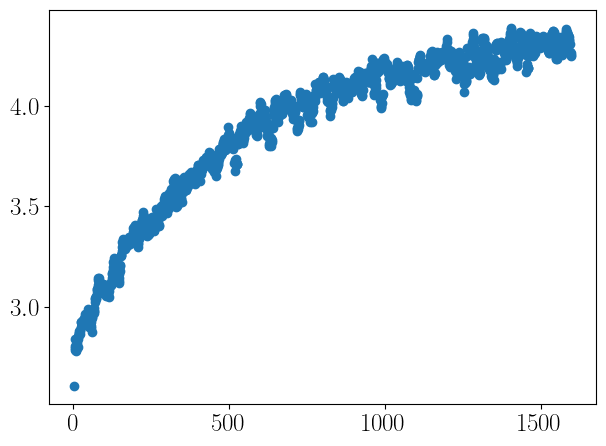

In [213]:
file_start = 0
file_end = 1600

hist_max = 4.0
hist_min = 0.0
N_bin = 50
dbin = (hist_max - hist_min) / N_bin
dt = 1
time = dt*np.arange(file_start,file_end  + 1 )

bins = np.arange(hist_min, hist_max  + dbin , dbin)  # Creating bin edges
s_entropy = np.zeros(file_end+1 - file_start)
avg_window = 10



for i in range(file_end+1 - file_start):
    file = file_start + i
    # Example: Reading from a text file with space-separated values
    filename = "/Users/jasonlaurie/Desktop/src-HGL/data/"+"psi."+str(file).zfill(6)  # Replace with your file path

    # Load data into a NumPy array
    psi = np.loadtxt(filename)

    intensity = np.sqrt(psi[:,1]**2 + psi[:,2]**2)

    # Compute histogram
    hist, bin_edges = np.histogram(intensity, bins=bins, density=True)
 
    s_entropy[i] = entropy(bins,hist)
    

fig, axes = plt.subplots()

s_avg = moving_average(s_entropy,avg_window)



#axes.plot(bins[1:], hist)
axes.scatter(time[avg_window//2:-(avg_window-2)//2] ,s_avg)
#axes.scatter(time ,s_entropy)
plt.tight_layout()




3.8693926443082547


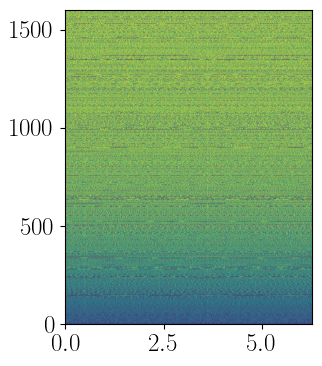

In [220]:
file_start = 0
file_end = 1600


intensityxt = np.zeros([N,file_end+1 - file_start])




for i in range(file_end+1 - file_start):
    file = file_start + i
    # Example: Reading from a text file with space-separated values
    filename = "/Users/jasonlaurie/Desktop/src-HGL/data/"+"psi."+str(file).zfill(6)  # Replace with your file path

    # Load data into a NumPy array
    psi = np.loadtxt(filename)

    intensityxt[:,i] = np.sqrt(psi[:,1]**2 + psi[:,2]**2)

    # Compute histogram
  
max_int = np.max(intensityxt)
print(max_int)

fig, axes = plt.subplots(figsize=(20,4))

axes.imshow(intensityxt.T,origin='lower',vmin=0, vmax=1, extent=[0, 2*np.pi, file_start, file_end], aspect=0.005)
plt.tight_layout()